# Test controlling proba of relevance through CLS to CLS only

In [53]:
from transformers import AutoTokenizer, BertTokenizer, BertForSequenceClassification, AutoModelForSequenceClassification
import torch
import numpy as np
import torch.nn.functional as F

# Load model and tokenizer
model_name = "cross-encoder/ms-marco-MiniLM-L12-v2"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, output_hidden_states=True)
model.eval()

model_name = "xpmir/cross-encoder-MiniLM-L12-infoNCE"
tokenizer4 = AutoTokenizer.from_pretrained(model_name)
model4 = AutoModelForSequenceClassification.from_pretrained(model_name, output_hidden_states=True)
model4.eval()

model_name = "castorini/monobert-large-msmarco"
tokenizer2 = BertTokenizer.from_pretrained(model_name)
model2 = BertForSequenceClassification.from_pretrained(model_name, output_hidden_states=True)
model2.eval()

model_name = "xpmir/cross-encoder-bert-base-infoNCE"
tokenizer3 = AutoTokenizer.from_pretrained(model_name)
model3 = AutoModelForSequenceClassification.from_pretrained(model_name, output_hidden_states=True)
model3.eval()

model_name = "xpmir/cross-encoder-bert-base-BCE"
tokenizer5 = AutoTokenizer.from_pretrained(model_name)
model5 = AutoModelForSequenceClassification.from_pretrained(model_name, output_hidden_states=True)
model5.eval()

# Define your query and documents
query = "what causes ear infection in adults"
doc = "The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science."

# Prepare inputs
inputs = tokenizer(query, doc, return_tensors="pt", padding=True, truncation=True)
inputs4 = tokenizer4(query, doc, return_tensors="pt", padding=True, truncation=True)
inputs2 = tokenizer2(query, doc, return_tensors="pt", padding=True, truncation=True)
inputs3 = tokenizer3(query, doc, return_tensors="pt", padding=True, truncation=True)
inputs5 = tokenizer5(query, doc, return_tensors="pt", padding=True, truncation=True)


# -------------------------
# 🔒 ABLATION: BLOCK other_tokens -> CLS
# -------------------------
sigmoid_list = []
sigmoid_list_2 = []
sigmoid_list_4 = []
sigmoid_list_5 = []
softmax_list = []

# Create a forward hook to modify attention scores
def prune_dropout(model, input, output):
    output[:,:,0,:] = 0
    output[:,:,0,0] = k/10
    return output

def prune_dropout_v2(model, input, output):
    alpha = k / 10  # goes from 0 to 1
    original = output[:, :, 0, :].clone()
    target = torch.zeros_like(original)
    target[:, :, 0] = 1.0  # CLS→CLS gets all the weight
    output[:, :, 0, :] = (1 - alpha) * original + alpha * target
    return output

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [54]:
LAYER_MINILM = -1
LAYER_BERT_BASE = -1
LAYER_BERT_LARGE = -1

In [37]:
# -------------------------
# MODEL 5: MonoBERT-base (xpmir/cross-encoder-bert-base-BCE)
# -------------------------
sigmoid_list_5 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model5.bert.encoder.layer):
        if idx > LAYER_BERT_BASE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout_v2)
            hooks.append(h)

    with torch.no_grad():
        out5 = model5(**inputs5, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_5.append(torch.sigmoid(out5.logits)[0])

# Clean up
del model5, tokenizer5, inputs5

In [38]:
# -------------------------
# MODEL 4: MonoBERT-base (xpmir/cross-encoder-bert-base-infoNCE)
# -------------------------
sigmoid_list_2 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model3.bert.encoder.layer):
        if idx > LAYER_BERT_BASE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout_v2)
            hooks.append(h)

    with torch.no_grad():
        out3 = model3(**inputs3, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_2.append(torch.sigmoid(out3.logits)[0])

# Clean up
del model3, tokenizer3, inputs3

In [39]:
# -------------------------
# MODEL 3: MonoBERT-large (castorini/monobert-large-msmarco)
# -------------------------
softmax_list = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model2.bert.encoder.layer):
        if idx > LAYER_BERT_LARGE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout_v2)
            hooks.append(h)

    with torch.no_grad():
        out2 = model2(**inputs2, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    softmax_list.append(torch.softmax(out2.logits, dim=-1)[0][1])  # Label 1 is "relevant"

# Clean up
del model2, tokenizer2, inputs2

In [40]:
# -------------------------
# MODEL 2: MiniLM with harder negatives (xpmir/cross-encoder-MiniLM-L12-infoNCE)
# -------------------------
sigmoid_list_4 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model4.bert.encoder.layer):
        if idx > LAYER_MINILM:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout_v2)
            hooks.append(h)

    with torch.no_grad():
        out4 = model4(**inputs4, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_4.append(torch.sigmoid(out4.logits)[0])

# Clean up
del model4, tokenizer4, inputs4

In [41]:
# -------------------------
# MODEL 1: MiniLM (cross-encoder/ms-marco-MiniLM-L12-v2)
# -------------------------
sigmoid_list = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model.bert.encoder.layer):
        if idx > LAYER_MINILM:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout_v2)
            hooks.append(h)

    with torch.no_grad():
        out = model(**inputs, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list.append(torch.sigmoid(out.logits)[0])

# Clean up
del model, tokenizer, inputs

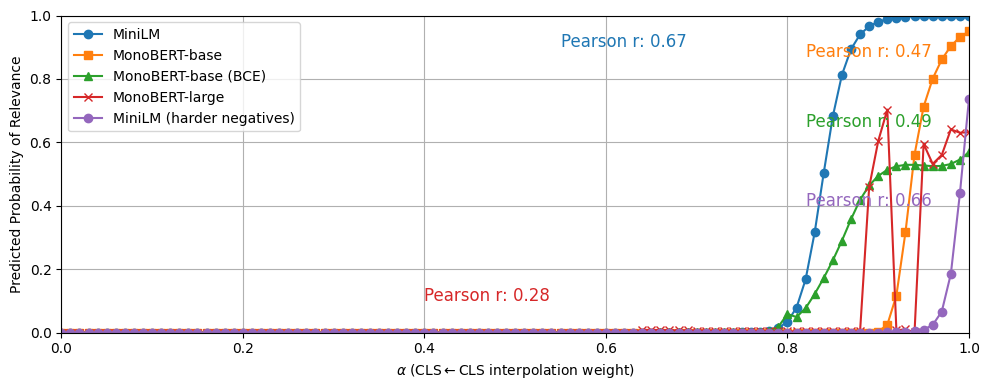

In [42]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

alpha_vals = np.linspace(0, 1, num=101)  # 101 points to match your [0] + list(np.logspace(...)) length

sigmoid_vals   = [v.item() for v in sigmoid_list]
sigmoid_vals_4 = [v.item() for v in sigmoid_list_4]
sigmoid_vals_2 = [v.item() for v in sigmoid_list_2]
sigmoid_vals_5 = [v.item() for v in sigmoid_list_5]
softmax_vals   = [v.item() for v in softmax_list]

corr_sigmoid   = pearsonr(alpha_vals, sigmoid_vals)[0]
corr_sigmoid_2 = pearsonr(alpha_vals, sigmoid_vals_2)[0]
corr_softmax   = pearsonr(alpha_vals, softmax_vals)[0]
corr_sigmoid_4 = pearsonr(alpha_vals, sigmoid_vals_4)[0]
corr_sigmoid_5 = pearsonr(alpha_vals, sigmoid_vals_5)[0]

plt.figure(figsize=(10, 4))
plt.text(0.55, 0.9,  f"Pearson r: {corr_sigmoid:.2f}",   color='C0', fontsize=12)
plt.text(0.82, 0.87, f"Pearson r: {corr_sigmoid_2:.2f}",  color='C1', fontsize=12)
plt.text(0.82, 0.4,  f"Pearson r: {corr_sigmoid_5:.2f}",  color='C4', fontsize=12)
plt.text(0.82, 0.65, f"Pearson r: {corr_softmax:.2f}",    color='C2', fontsize=12)
plt.text(0.4,  0.1,  f"Pearson r: {corr_sigmoid_4:.2f}",  color='C3', fontsize=12)

plt.plot(alpha_vals, sigmoid_vals,   marker='o', label="MiniLM")
plt.plot(alpha_vals, sigmoid_vals_2, marker='s', label="MonoBERT-base")
plt.plot(alpha_vals, sigmoid_vals_5, marker='^', label="MonoBERT-base (BCE)")
plt.plot(alpha_vals, softmax_vals,   marker='x', label="MonoBERT-large")
plt.plot(alpha_vals, sigmoid_vals_4, marker='o', label="MiniLM (harder negatives)")

plt.legend(loc="upper left")
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.xlabel(r"$\alpha$ (CLS$\leftarrow$CLS interpolation weight)")
plt.ylabel("Predicted Probability of Relevance")
plt.grid(True)
plt.tight_layout()
# plt.savefig("control_xp_cls_to_cls_v3.pdf", format="pdf")
plt.show()

# Original approach 

In [55]:
# -------------------------
# MODEL 5: MonoBERT-base (xpmir/cross-encoder-bert-base-BCE)
# -------------------------
sigmoid_list_5 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model5.bert.encoder.layer):
        if idx > LAYER_BERT_BASE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout)
            hooks.append(h)

    with torch.no_grad():
        out5 = model5(**inputs5, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_5.append(torch.sigmoid(out5.logits)[0])

# Clean up
del model5, tokenizer5, inputs5

In [56]:
# -------------------------
# MODEL 4: MonoBERT-base (xpmir/cross-encoder-bert-base-infoNCE)
# -------------------------
sigmoid_list_2 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model3.bert.encoder.layer):
        if idx > LAYER_BERT_BASE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout)
            hooks.append(h)

    with torch.no_grad():
        out3 = model3(**inputs3, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_2.append(torch.sigmoid(out3.logits)[0])

# Clean up
del model3, tokenizer3, inputs3

In [57]:
# -------------------------
# MODEL 3: MonoBERT-large (castorini/monobert-large-msmarco)
# -------------------------
softmax_list = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model2.bert.encoder.layer):
        if idx > LAYER_BERT_LARGE:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout)
            hooks.append(h)

    with torch.no_grad():
        out2 = model2(**inputs2, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    softmax_list.append(torch.softmax(out2.logits, dim=-1)[0][1])  # Label 1 is "relevant"

# Clean up
del model2, tokenizer2, inputs2

In [58]:
# -------------------------
# MODEL 2: MiniLM with harder negatives (xpmir/cross-encoder-MiniLM-L12-infoNCE)
# -------------------------
sigmoid_list_4 = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model4.bert.encoder.layer):
        if idx > LAYER_MINILM:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout)
            hooks.append(h)

    with torch.no_grad():
        out4 = model4(**inputs4, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list_4.append(torch.sigmoid(out4.logits)[0])

# Clean up
del model4, tokenizer4, inputs4

In [59]:
# -------------------------
# MODEL 1: MiniLM (cross-encoder/ms-marco-MiniLM-L12-v2)
# -------------------------
sigmoid_list = []

for k in [0] + list(np.logspace(0, 1, num=100)):
    hooks = []
    for idx, layer in enumerate(model.bert.encoder.layer):
        if idx > LAYER_MINILM:
            h = layer.attention.self.dropout.register_forward_hook(prune_dropout)
            hooks.append(h)

    with torch.no_grad():
        out = model(**inputs, output_attentions=True, output_hidden_states=True)

    for h in hooks:
        h.remove()

    sigmoid_list.append(torch.sigmoid(out.logits)[0])

# Clean up
del model, tokenizer, inputs

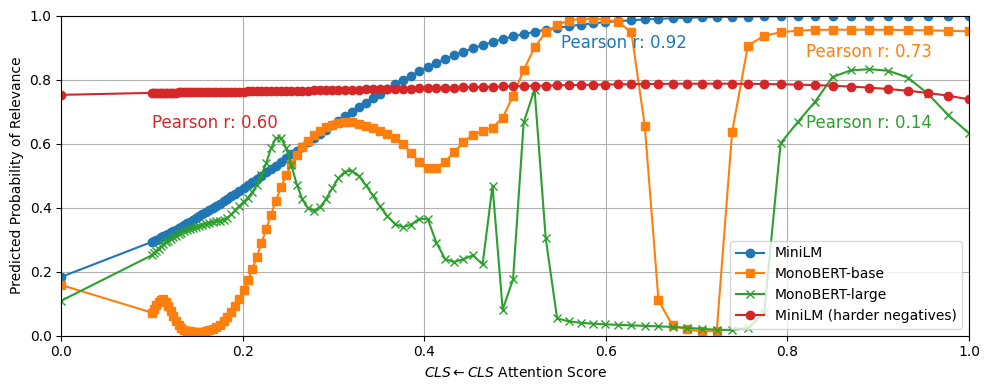

In [61]:
import numpy as np
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
sigmoid_vals = [v.item() for v in sigmoid_list]
sigmoid_vals_4 = [v.item() for v in sigmoid_list_4]
sigmoid_vals_2 = [v.item() for v in sigmoid_list_2]
sigmoid_vals_5 = [v.item() for v in sigmoid_list_5]
softmax_vals = [v.item() for v in softmax_list]

corr_sigmoid = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals)[0]
corr_sigmoid_2 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_2)[0]
corr_softmax = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), softmax_vals)[0]
corr_sigmoid_4 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_4)[0]
corr_sigmoid_5 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_5)[0]

plt.figure(figsize=(10, 4))
plt.text(0.55, 0.9, f"Pearson r: {corr_sigmoid:.2f}", color='C0', fontsize=12)
plt.text(0.82, 0.87, f"Pearson r: {corr_sigmoid_2:.2f}", color='C1', fontsize=12)
plt.text(0.82, 0.65, f"Pearson r: {corr_softmax:.2f}", color='C2', fontsize=12)
plt.text(0.1, 0.65, f"Pearson r: {corr_sigmoid_4:.2f}", color='C3', fontsize=12)
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list, marker='o', label="MiniLM")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list_2, marker='s', label="MonoBERT-base")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), softmax_list, marker='x', label="MonoBERT-large")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list_4, marker='o', label="MiniLM (harder negatives)")

# plt.axhline(y=(original_proba+original_proba_2+original_proba_3+original_proba_4)/4, color='red', linestyle='--', linewidth=3, label='Avg. original proba')
plt.legend(["MiniLM", "MonoBERT-base", "MonoBERT-large", "MiniLM (harder negatives)"], loc="lower right")
plt.xlim(0, 1.0)
plt.ylim(0,1.0)
plt.xlabel(r"$CLS \leftarrow CLS$ Attention Score")
plt.ylabel("Predicted Probability of Relevance")
plt.grid(True)
plt.tight_layout()
plt.savefig("control_xp_cls_to_cls_v2.pdf", format="pdf")
plt.show()

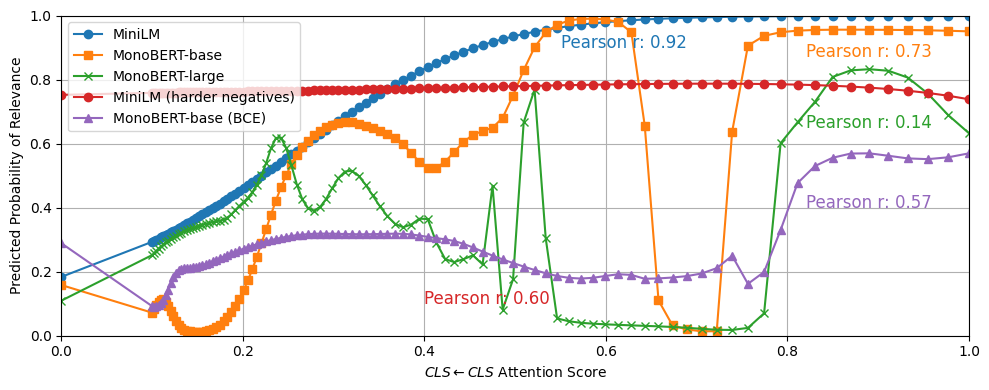

In [51]:
import numpy as np
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
sigmoid_vals = [v.item() for v in sigmoid_list]
sigmoid_vals_4 = [v.item() for v in sigmoid_list_4]
sigmoid_vals_2 = [v.item() for v in sigmoid_list_2]
sigmoid_vals_5 = [v.item() for v in sigmoid_list_5]
softmax_vals = [v.item() for v in softmax_list]

corr_sigmoid = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals)[0]
corr_sigmoid_2 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_2)[0]
corr_softmax = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), softmax_vals)[0]
corr_sigmoid_4 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_4)[0]
corr_sigmoid_5 = pearsonr([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_vals_5)[0]

plt.figure(figsize=(10, 4))
plt.text(0.55, 0.9, f"Pearson r: {corr_sigmoid:.2f}", color='C0', fontsize=12)
plt.text(0.82, 0.87, f"Pearson r: {corr_sigmoid_2:.2f}", color='C1', fontsize=12)
plt.text(0.82, 0.65, f"Pearson r: {corr_softmax:.2f}", color='C2', fontsize=12)
plt.text(0.4, 0.1, f"Pearson r: {corr_sigmoid_4:.2f}", color='C3', fontsize=12)
plt.text(0.82, 0.4, f"Pearson r: {corr_sigmoid_5:.2f}", color='C4', fontsize=12)
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list, marker='o', label="MiniLM")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list_2, marker='s', label="MonoBERT-base")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), softmax_list, marker='x', label="MonoBERT-large")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list_4, marker='o', label="MiniLM (harder negatives)")
plt.plot([0] + list(np.logspace(0, 1, num=100)/10), sigmoid_list_5, marker='^', label="MonoBERT-base (BCE)")

# plt.axhline(y=(original_proba+original_proba_2+original_proba_3+original_proba_4)/4, color='red', linestyle='--', linewidth=3, label='Avg. original proba')
plt.legend(["MiniLM", "MonoBERT-base", "MonoBERT-large", "MiniLM (harder negatives)", "MonoBERT-base (BCE)"], loc="upper left")
plt.xlim(0, 1.0)
plt.ylim(0,1.0)
plt.xlabel(r"$CLS \leftarrow CLS$ Attention Score")
plt.ylabel("Predicted Probability of Relevance")
plt.grid(True)
plt.tight_layout()
# plt.savefig("control_xp_cls_to_cls_v2.pdf", format="pdf")
plt.show()